In [8]:
import pandas as pd

df = pd.read_csv("C:/Users/anast/Downloads/regretion.csv")

df = df.rename(columns={
    "лемма": "lemma",
    "-оу": "n_ou",
    "-ови": "n_ovi",
    "личность": "personal_meaning",
    "количество слогов": "syllables",
    "основа на -в": "stem_v",
    "тип основы": "stem_type",
})

df["total"] = df["n_ou"] + df["n_ovi"]
df = df[df["total"] > 0].copy()

df["prop_ovi"] = df["n_ovi"] / df["total"]

In [9]:
cat_vars = ["personal_meaning", "stem_v", "stem_type"]

df_encoded = pd.get_dummies(df, columns=cat_vars, drop_first=True)

for var in cat_vars:
    print(df[var].value_counts(), "\n")

personal_meaning
личное, собственное        104
неличное, несобственное     76
неличное, собственное       57
личное, несобственное       37
Name: count, dtype: int64 

stem_v
нет    240
да      34
Name: count, dtype: int64 

stem_type
твёрдый    184
мягкий      90
Name: count, dtype: int64 



In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

predictors = ["syllables"] + [c for c in df_encoded.columns
                               if c.startswith(tuple(cat_vars))]

X_vif = df_encoded[predictors].astype(float)
X_vif = X_vif.assign(const=1)

vif_data = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_data) # все значения VIF ниже 5, мультиколлинеарности нет

                                   variable        VIF
0                                 syllables   1.114591
1      personal_meaning_личное, собственное   2.473451
2  personal_meaning_неличное, несобственное   2.237377
3    personal_meaning_неличное, собственное   2.084213
4                                stem_v_нет   1.103238
5                         stem_type_твёрдый   1.061569
6                                     const  28.454282


In [12]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

formula = "prop_ovi ~ syllables + C(personal_meaning) + C(stem_v) + C(stem_type)"

model = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Binomial(),
    freq_weights=df["total"]
)

result = model.fit()
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               prop_ovi   No. Observations:                  274
Model:                            GLM   Df Residuals:                     1129
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -438.58
Date:                Tue, 25 Aug 2026   Deviance:                       580.12
Time:                        17:31:27   Pearson chi2:                     697.
No. Iterations:                     8   Pseudo R-squ. (CS):             0.7578
Covariance Type:            nonrobust                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [13]:
odds_ratios = np.exp(result.params)
conf = np.exp(result.conf_int())
conf.columns = ["OR_lower", "OR_upper"]
summary_or = pd.concat([odds_ratios.rename("OR"), conf], axis=1)
print(summary_or)

                                                       OR  OR_lower   OR_upper
Intercept                                        0.126955  0.066636   0.241873
C(personal_meaning)[T.личное, собственное]      13.496219  8.189210  22.242429
C(personal_meaning)[T.неличное, несобственное]   0.186953  0.071196   0.490918
C(personal_meaning)[T.неличное, собственное]     0.062547  0.008432   0.463955
C(stem_v)[T.нет]                                 6.930900  4.120224  11.658924
C(stem_type)[T.твёрдый]                          0.414070  0.267221   0.641618
syllables                                        0.520650  0.433353   0.625532


In [14]:
print("Pseudo R² (McFadden):", 1 - result.llf / result.llnull)

Pseudo R² (McFadden): 0.3069831770423628


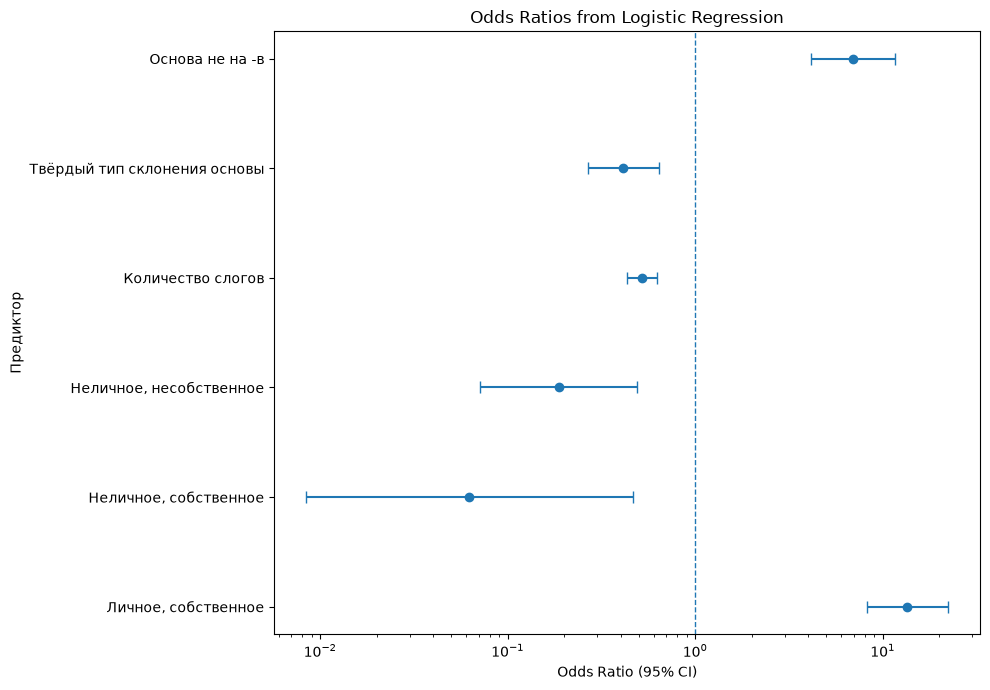

In [18]:
import numpy as np
import matplotlib.pyplot as plt

odds_ratios = np.exp(result.params)

conf = np.exp(result.conf_int())

odds_ratios = odds_ratios.drop("Intercept")
conf = conf.drop("Intercept")

predictor_order = [
    "C(personal_meaning)[T.личное, собственное]",
    "C(personal_meaning)[T.неличное, собственное]",
    "C(personal_meaning)[T.неличное, несобственное]",
    "syllables",
    "C(stem_type)[T.твёрдый]",
    "C(stem_v)[T.нет]"
]

odds_ratios = odds_ratios.loc[predictor_order]
conf = conf.loc[predictor_order]

labels = [
    "Личное, собственное",
    "Неличное, собственное",
    "Неличное, несобственное",
    "Количество слогов",
    "Твёрдый тип склонения основы",
    "Основа не на -в"
]

lower_error = odds_ratios - conf[0]
upper_error = conf[1] - odds_ratios

plt.figure(figsize=(10, 7))

plt.errorbar(
    odds_ratios.values,
    range(len(odds_ratios)),
    xerr=[lower_error.values, upper_error.values],
    fmt='o',
    capsize=4
)

plt.axvline(
    1,
    linestyle='--',
    linewidth=1
)

plt.xscale('log')

plt.yticks(
    range(len(labels)),
    labels
)

plt.xlabel("Odds Ratio (95% CI)")
plt.ylabel("Предиктор")
plt.title("Odds Ratios from Logistic Regression")

plt.tight_layout()
plt.show()

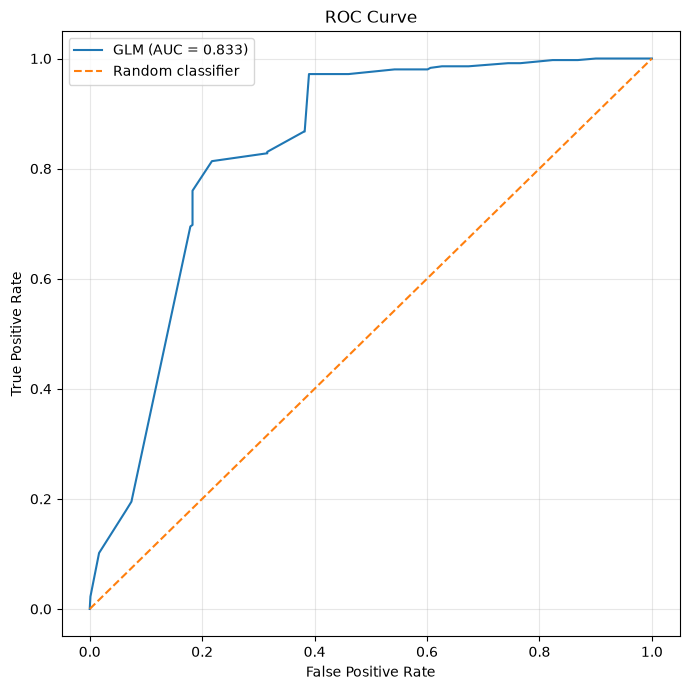

AUC = 0.833


In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

pred_prob = result.predict(df)

n_ovi = np.round(df["prop_ovi"] * df["total"]).astype(int)

n_no_ovi = df["total"].astype(int) - n_ovi

y_true = np.concatenate([
    np.ones(n_ovi.sum(), dtype=int),
    np.zeros(n_no_ovi.sum(), dtype=int)
])

y_score = np.concatenate([
    np.repeat(pred_prob.values, n_ovi),
    np.repeat(pred_prob.values, n_no_ovi)
])

fpr, tpr, thresholds = roc_curve(y_true, y_score)

auc = roc_auc_score(y_true, y_score)

plt.figure(figsize=(7, 7))

plt.plot(
    fpr,
    tpr,
    label=f"GLM (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AUC = {auc:.3f}")

Все четыре параметра, рассмотренные при анализе, являются статистически значимыми -- p < 0.01 (параметры "(не)личное имя" и "собственное/нарицательное имя" были объединены в один вследствие их влияния друг на друга).

Сильнее всего на тяготение к выбору окончания -ови влияют две характеристики леммы: 1) личное собственное имя, 2) основа НЕ на -в. Сильнее всего на тяготение к выбору окончания -оу влияет принадлежность основы леммы к твердому типу склонения, а также рост числа слогов (чем больше слогов, тем вероятнее выбор в пользу окончания -оу).

Качество модели: pseudo R² = 0.307, ROC-AUC = 0.833